Selected data shape: (16327, 6)


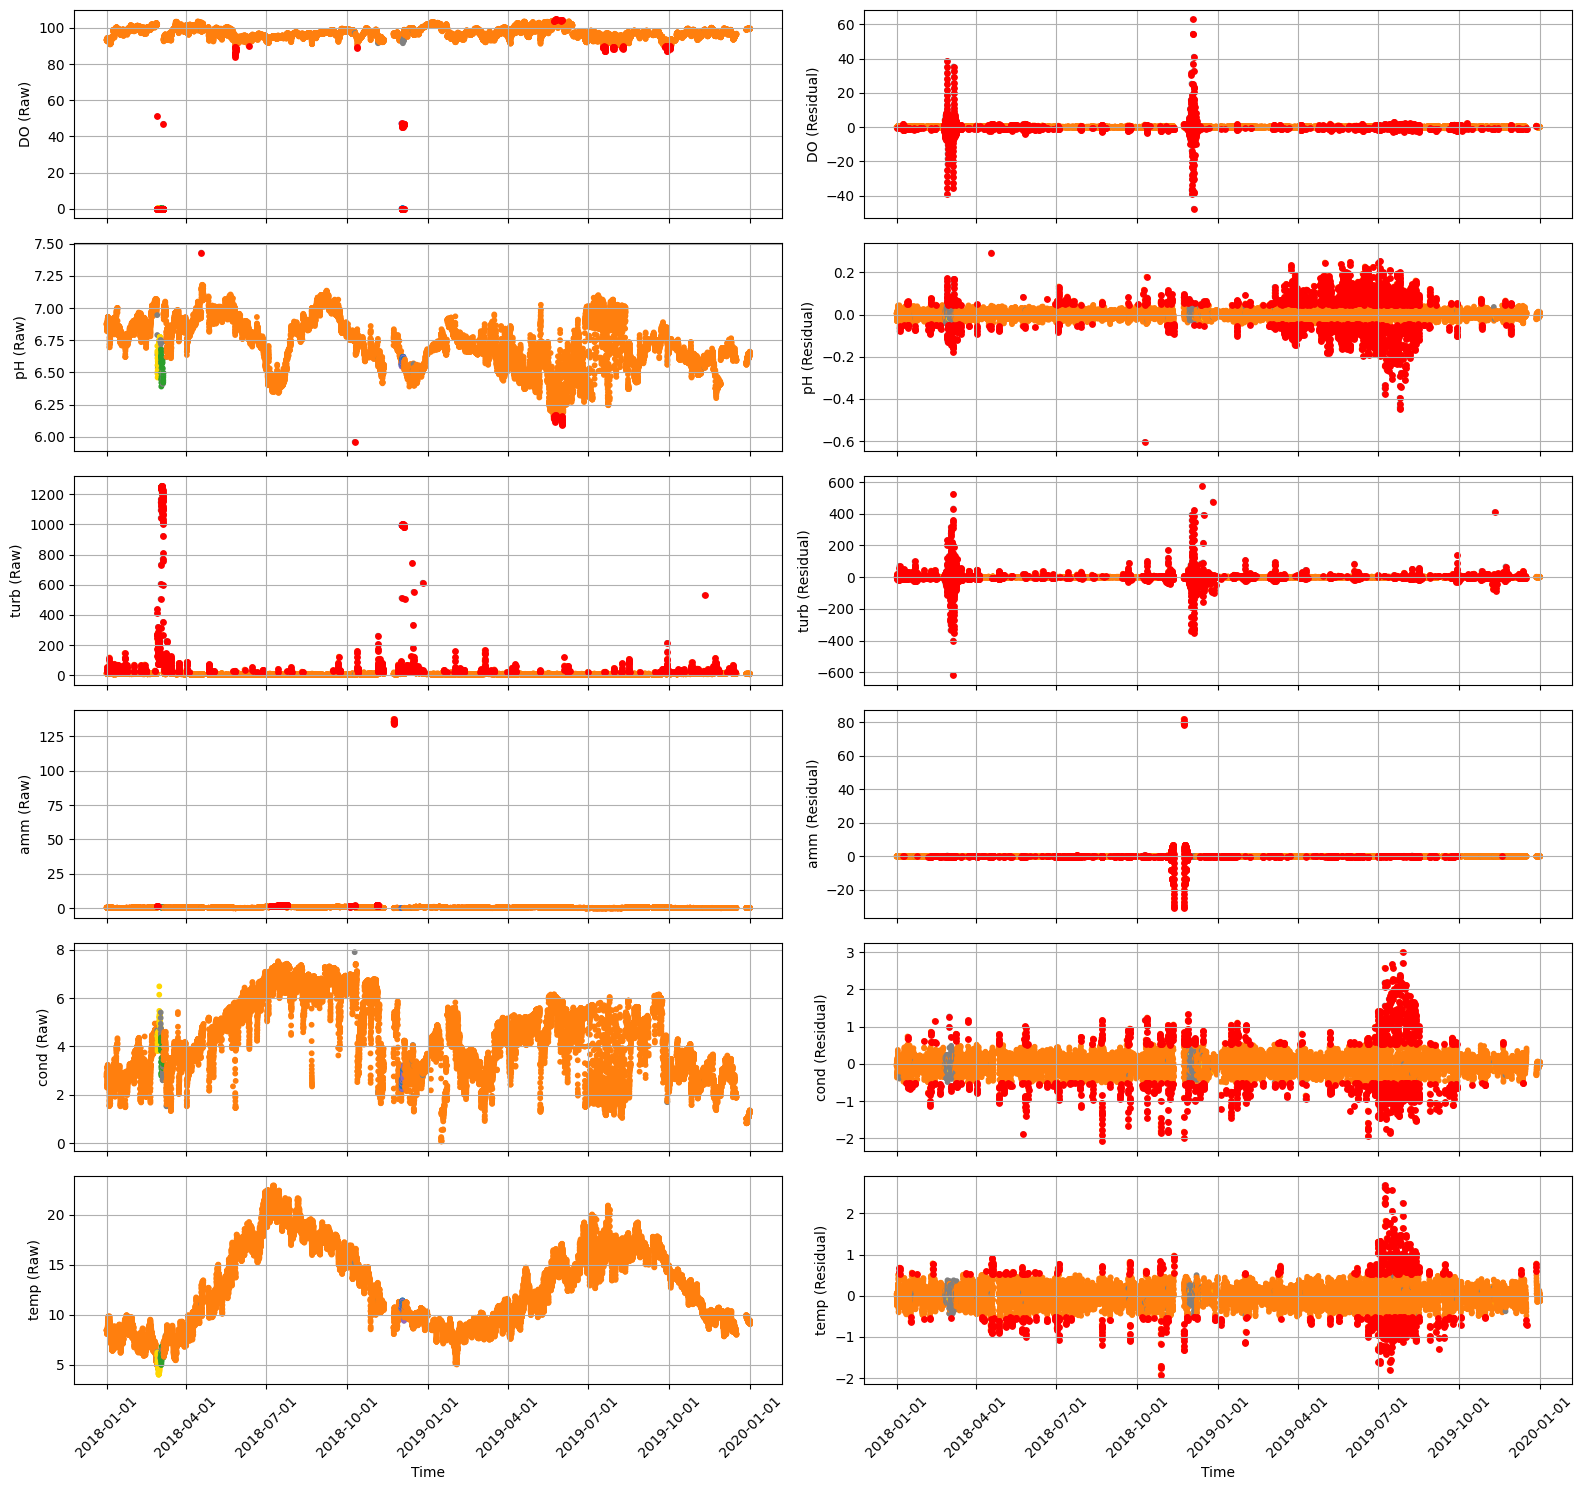

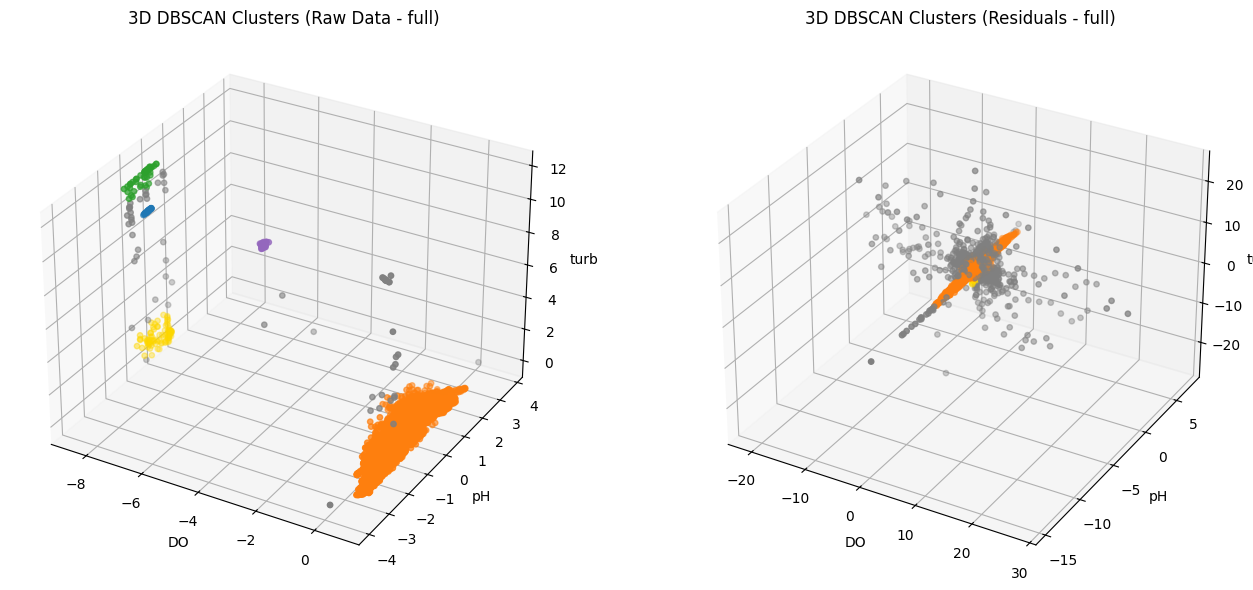

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
from statsmodels.tsa.seasonal import MSTL
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

# ========== Shared Functions ==========
def compute_iqr_outliers(df, iqr_multiplier=1.5):
    outliers = pd.DataFrame(index=df.index, columns=df.columns)
    for col in df.columns:
        series = df[col].dropna()
        Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - iqr_multiplier * IQR, Q3 + iqr_multiplier * IQR
        outliers[col] = (df[col] < lower) | (df[col] > upper)
    return outliers.fillna(False)

custom_palette = ["#FF7F0E", "#FFD700", "#2CA02C", "#9467BD", "#1F77B4", "#D62728", "#8C564B", "#E377C2"]
def assign_colors(labels):
    return ['gray' if l == -1 else custom_palette[l % len(custom_palette)] for l in labels]

# MSTL plot & residual extraction function with saving plots
def plot_and_save_mstl(series, var_name, save_dir):
    possible_periods = [365*24, 24]  # yearly, daily hours
    valid_periods = [p for p in possible_periods if p <= len(series) // 2]
    mstl = MSTL(series, periods=valid_periods).fit()
    
    fig, axs = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
    axs[0].plot(series.index, series, label='Original')
    axs[0].set_title(f'{var_name} - Original')
    axs[1].plot(series.index, mstl.trend, label='Trend', color='orange')
    axs[1].set_title('Trend')
    axs[2].plot(series.index, mstl.seasonal, label='Seasonal', color='green')
    axs[2].set_title('Seasonal')
    residual = series - mstl.trend - mstl.seasonal
    axs[3].plot(series.index, residual, label='Residual', color='red')
    axs[3].set_title('Residual')
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f"{var_name}_mstl_decomposition.png"), dpi=300)
    plt.close(fig)
    
    return residual

# ========== Config ==========
mode = "iqr_only"  # "full" or "iqr_only"
start_date, end_date = "2018", "2019"

# ========== Step 1: Load Data ==========
file_paths = {
    'DO': 'E14115A-do-i-subdaily-pct.csv',
    'pH': 'E14115A-ph-i-subdaily.csv',
    'turb': 'E14115A-turb-i-subdaily-ntu.csv',
    'amm': 'E14115A-amm-i-subdaily-mgL.csv',
    'cond': 'E14115A-cond-i-subdaily-uS.csv',
    'temp': 'E14115A-temp-i-subdaily-C.csv'
}
scale_factors = {'DO': 1, 'pH': 1, 'turb': 1, 'amm': 1, 'cond': 0.01, 'temp': 1}

data_dict = {k: pd.read_csv(path).reset_index(drop=True) for k, path in file_paths.items()}
time_data = pd.to_datetime(data_dict['temp']['dateTime']).reset_index(drop=True)
value_data = {k: data_dict[k]['value'] * scale_factors[k] for k in data_dict}

min_len = min([len(v) for v in value_data.values()] + [len(time_data)])
value_data = {k: v[:min_len].reset_index(drop=True) for k, v in value_data.items()}
time_data = time_data[:min_len].reset_index(drop=True)

df_raw = pd.DataFrame(value_data)
df_raw.index = time_data
df_raw = df_raw[~df_raw.index.duplicated(keep='first')]
df_hourly = df_raw.resample('h').mean().dropna(how='all')
df_selected = df_hourly.loc[start_date:end_date]
print(f"Selected data shape: {df_selected.shape}")

# ========== Create directory for MSTL plots ==========
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
mstl_dir = f"mstl_plots_{timestamp}"
os.makedirs(mstl_dir, exist_ok=True)

# ========== Step 2: Compute MSTL residuals and save decomposition plots ==========
residuals = pd.DataFrame(index=df_selected.index)
for col in df_selected.columns:
    series = df_selected[col].dropna()
    if len(series) < 24:
        print(f"Skipping {col} (too short)")
        continue
    try:
        residuals[col] = plot_and_save_mstl(series, col, mstl_dir)
    except Exception as e:
        print(f"Skipping {col} due to MSTL error: {e}")

residuals = residuals.dropna()
if residuals.empty:
    raise ValueError("Residuals empty after MSTL.")

# ========== Step 3: Mode Selection ==========
if mode == "iqr_only":
    # Filter original data using IQR on MSTL residuals
    iqr_outliers_resid = compute_iqr_outliers(residuals)
    df_selected_filtered = df_selected[iqr_outliers_resid.any(axis=1)]
    residuals_filtered = residuals[iqr_outliers_resid.any(axis=1)]
    print(f"IQR-Flagged shape after MSTL residual filtering: {df_selected_filtered.shape}")
    if df_selected_filtered.empty:
        raise ValueError("No IQR outliers found after MSTL residual filtering.")
else:
    df_selected_filtered = df_selected
    residuals_filtered = residuals

# Save filtered dataset to CSV
df_selected_filtered.to_csv(f"iqr_filtered_dataset_{mode}_{start_date}_to_{end_date}.csv")

# ========== Step 4: Scaling ==========
scaler_raw, scaler_resid = StandardScaler(), StandardScaler()
X_raw = scaler_raw.fit_transform(df_selected_filtered.loc[residuals_filtered.index])[:, :3]
X_resid = scaler_resid.fit_transform(residuals_filtered)[:, :3]
feature_names = df_selected_filtered.columns[:3].tolist()

# ========== Step 5: DBSCAN ==========
db_raw = DBSCAN(eps=0.5, min_samples=10).fit(X_raw)
db_resid = DBSCAN(eps=0.5, min_samples=10).fit(X_resid)
labels_raw, labels_resid = db_raw.labels_, db_resid.labels_

# ========== Step 6: Time Series Plots ==========
n_vars = len(residuals_filtered.columns)
fig, axs = plt.subplots(n_vars, 2, figsize=(16, 2.5 * n_vars), sharex='col')
if n_vars == 1: axs = [axs]

for i, col in enumerate(residuals_filtered.columns):
    axs[i][0].scatter(residuals_filtered.index, df_selected_filtered.loc[residuals_filtered.index, col],
                      c=assign_colors(labels_raw), s=10)
    raw_outliers = df_selected_filtered.loc[residuals_filtered.index][
        compute_iqr_outliers(df_selected_filtered.loc[residuals_filtered.index])[col]
    ]
    axs[i][0].scatter(raw_outliers.index, raw_outliers[col], color='red', s=15, marker='o')
    axs[i][0].set_ylabel(f"{col} (Raw)")
    axs[i][0].grid(True)

    axs[i][1].scatter(residuals_filtered.index, residuals_filtered[col],
                      c=assign_colors(labels_resid), s=10)
    resid_outliers = residuals_filtered[compute_iqr_outliers(residuals_filtered)[col]]
    axs[i][1].scatter(resid_outliers.index, resid_outliers[col], color='red', s=15, marker='o')
    axs[i][1].set_ylabel(f"{col} (Residual)")
    axs[i][1].grid(True)

for ax in axs[-1]:
    ax.set_xlabel("Time")
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ========== Step 7: 3D Cluster Plots ==========
fig_cluster = plt.figure(figsize=(14, 6))
ax1 = fig_cluster.add_subplot(1, 2, 1, projection='3d')
ax1.scatter(X_raw[:, 0], X_raw[:, 1], X_raw[:, 2], c=assign_colors(labels_raw), s=15)
ax1.set_title(f'3D DBSCAN Clusters (Raw Data - {mode})')
ax1.set_xlabel(feature_names[0])
ax1.set_ylabel(feature_names[1])
ax1.set_zlabel(feature_names[2])

ax2 = fig_cluster.add_subplot(1, 2, 2, projection='3d')
ax2.scatter(X_resid[:, 0], X_resid[:, 1], X_resid[:, 2], c=assign_colors(labels_resid), s=15)
ax2.set_title(f'3D DBSCAN Clusters (Residuals - {mode})')
ax2.set_xlabel(feature_names[0])
ax2.set_ylabel(feature_names[1])
ax2.set_zlabel(feature_names[2])

plt.tight_layout()
plt.savefig(f"CARBIS_STREAM_{mode.upper()}_3D_DBSCAN_{start_date}_to_{end_date}.png", dpi=300)
plt.show()
